**NOTICE:**  
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.

# 05. Advanced MCMC Techniques
This notebook covers advanced Markov Chain Monte Carlo methods and diagnostics.

## What You'll Learn

- Multiple chains and convergence diagnostics
- Comparing MCMC samplers (RWMH, ARWMH, DEMCz, DEMCzs, HMC)
- Effective sample size and autocorrelation
- Adaptive sampling strategies
- Handling multimodal posteriors
- Hierarchical models
- Sampler tuning and optimization

**Note:** Many code blocks in this notebook have long run times due to the computationally expensive methods we are testing. Please allow between 5-10 minutes of runtime per block before becoming concerned. 

## Set Up

In [1]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from System.Collections.Generic import List

# Load Numerics DLL
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

from Numerics.Distributions import Normal, Uniform, Weibull, IUnivariateDistribution
from Numerics.Sampling.MCMC import MCMCSampler, LogLikelihood, RWMH, ARWMH, DEMCz, DEMCzs, HMC, MCMCResults, MCMCDiagnostics
from Numerics.Data.Statistics import Autocorrelation
from Numerics.Mathematics.Optimization import ParameterSet 
from Numerics.Mathematics.LinearAlgebra import Matrix
from helper_functions import convert_to_dotnet_array

print("✓ Setup complete")

✓ Setup complete


## Helper Functions
The basics of these functions are covered in previous notebooks. We define these here as helper functions to use in the rest of the notebook for efficiency.

In [2]:
def extract_chain_samples(results, param_indx):
    """Extract parameter samples from MCMC sampler."""
    chains = []
    for c in range(len(results.MarkovChains)):
        chain_c = [results.MarkovChains[c][i].Values[param_indx]
                   for i in range(len(results.MarkovChains[c]))]
        chains.append(chain_c)
    return chains

def plot_trace(samples, param_names, title="Trace Plots"):
    """Plot MCMC trace plots."""
    n_params = len(samples)
    fig, axes = plt.subplots(n_params, 1, figsize=(12, 3*n_params))

    if n_params == 1:
        axes = [axes]

    for i, (sample, name) in enumerate(zip(samples, param_names)):
        axes[i].plot(sample, linewidth=0.5, alpha=0.7)
        axes[i].set_ylabel(name, fontsize=11)
        axes[i].set_xlabel('Iteration', fontsize=11)
        axes[i].grid(True, alpha=0.3)

        # Add mean line
        axes[i].axhline(np.mean(sample), color='red', linestyle='--',
                       linewidth=2, label=f'Mean: {np.mean(sample):.3f}')
        axes[i].legend(fontsize=9)

    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

def plot_posterior(samples, param_names, true_values=None, title="Posterior Distributions"):
    """Plot posterior distributions."""
    colors = 'steelblue'
    n_params = len(samples)
    fig, axes = plt.subplots(1, n_params, figsize=(5*n_params, 4))

    if n_params == 1:
        axes = [axes]

    for i, (sample, name) in enumerate(zip(samples, param_names)):
        axes[i].hist(sample, bins=50, density=True, alpha=0.7,
                    color=colors)
        axes[i].set_xlabel(name, fontsize=12)
        axes[i].set_ylabel('Density', fontsize=12)
        axes[i].grid(True, alpha=0.3, axis='y')

        if true_values is not None:
            axes[i].axvline(true_values[i], color='red', linestyle='--',
                          linewidth=2, label=f'True: {true_values[i]:.3f}')
            axes[i].legend(fontsize=10)

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()



## 1. Multiple Chains for Convergence Assessment
Running multiple chains helps diagnose convergence and assess mixing.

In [3]:
# Generate synthetic data
np.random.seed(1234)
true_mu = 100
true_sigma = 15
data_net =  Normal(true_mu, true_sigma).GenerateRandomValues(100, 1234)
data = list(data_net)  # Convert to Python list for easier handling

# Define priors
priors = List[IUnivariateDistribution]()
priors.Add(Uniform(50, 150))   # Prior for mu
priors.Add(Uniform(5, 30))     # Prior for sigma

# Log-likelihood function
def log_likelihood(params):
    dist = Normal(params[0], params[1])
    return sum(dist.LogPDF(x) for x in data)

# Convert to .NET Func
log_lik_func = LogLikelihood(log_likelihood)

# Run 4 independent chains 
n_chains = 4
chains_mu = []
chains_sigma = []

proposal = Matrix(2, 2)
proposal[0, 0] = 1.0   # variance for mu
proposal[1, 1] = 1.0   # variance for sigma
proposal[0, 1] = 0.0   # covariance
proposal[1, 0] = 0.0

sampler = RWMH(priors, log_lik_func, proposal)
sampler.Initialize = MCMCSampler.InitializationType.Randomize
sampler.NumberOfChains = n_chains

sampler.Sample()

results = MCMCResults(sampler)

print("✓ RWMH Complete")

✓ RWMH Complete


## 2. Convergence Diagnostics: R-hat

R-hat (Gelman-Rubin statistic) compares within-chain and between-chain variance.

- **R-hat < 1.01**: Excellent convergence
- **R-hat < 1.05**: Good convergence
- **R-hat > 1.1**: Poor convergence, run longer

**Note:** R-hat is only meaningful when chains are comparable length and well mixed.

Convergence Diagnostics (R-hat):
μ:     1.0004  ✓ Converged
σ:     1.0003  ✓ Converged


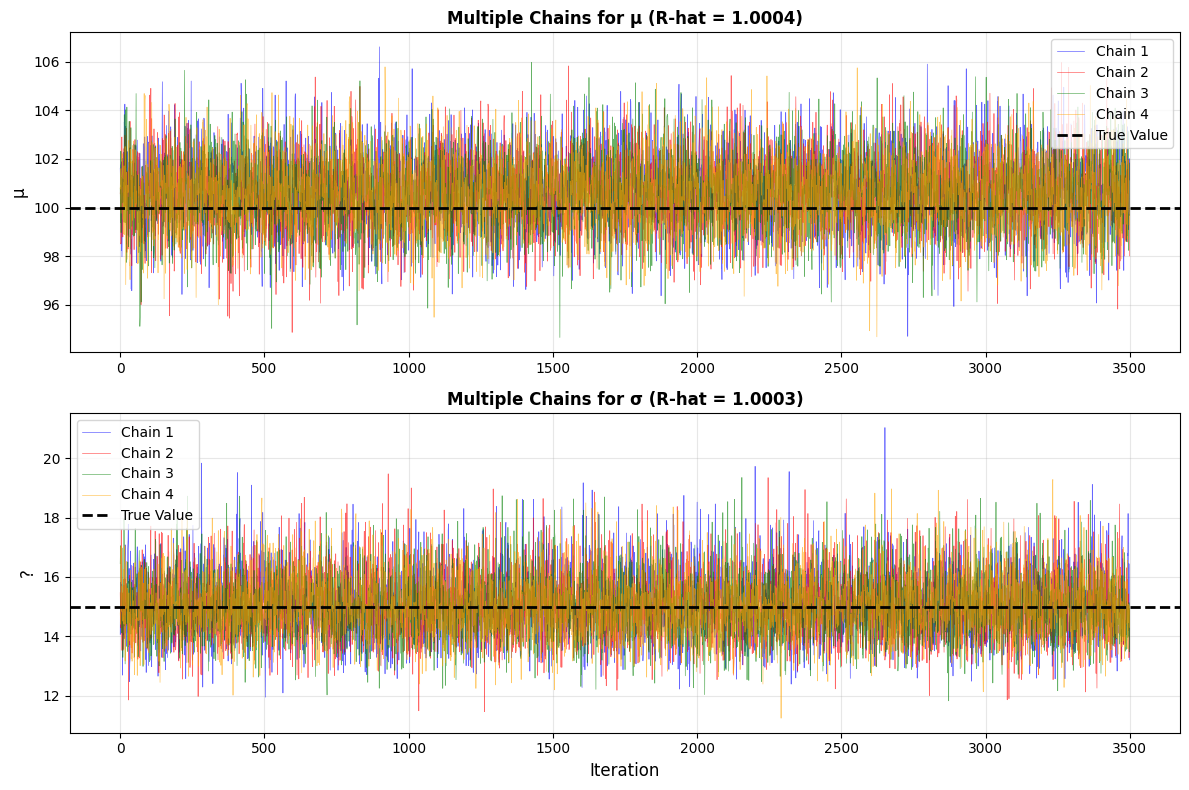

In [4]:
# Extract samples
chains_mu = extract_chain_samples(results, 0)
chains_sigma = extract_chain_samples(results, 1)

# Compute R-hat with Gelman-Rubin from MCMC Diagnostics
markov_chains = results.MarkovChains
rhat = MCMCDiagnostics.GelmanRubin(markov_chains, int(0))
rhat_mu = float(rhat[0])
rhat_sigma = float(rhat[1])

print("Convergence Diagnostics (R-hat):")
print(f"μ:     {rhat_mu:.4f}  {'✓ Converged' if rhat_mu < 1.05 else 'Χ Not converged'}")
print(f"σ:     {rhat_sigma:.4f}  {'✓ Converged' if rhat_sigma < 1.05 else 'Χ Not converged'}")

# Plot chains
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

colors = ['blue', 'red', 'green', 'orange']
for i, chain in enumerate(chains_mu):
    axes[0].plot(chain, alpha=0.6, linewidth=0.5, label=f'Chain {i+1}', color=colors[i])
axes[0].axhline(true_mu, color='black', linestyle='--', linewidth=2, label='True Value')
axes[0].set_ylabel('μ', fontsize=12)
axes[0].set_title(f'Multiple Chains for μ (R-hat = {rhat_mu:.4f})', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

for i, chain in enumerate(chains_sigma):
    axes[1].plot(chain, alpha=0.6, linewidth=0.5, label=f'Chain {i+1}', color=colors[i])
axes[1].axhline(true_sigma, color='black', linestyle='--', linewidth=2, label='True Value')
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('?', fontsize=12)
axes[1].set_title(f'Multiple Chains for σ (R-hat = {rhat_sigma:.4f})', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## 3. Effective Sample Size (ESS)

ESS accounts for autocorrelation in MCMC samples. Higher is better.

- **ESS > 1000**: Good for inference
- **ESS < 100**: May need longer chains

Effective Sample Size


,Metric,Value
0,Total samples,14000.00
1,ESS (μ),11052.62
2,ESS efficiency (μ),78.95
3,ESS (σ),12431.72
4,ESS efficiency (σ),88.80


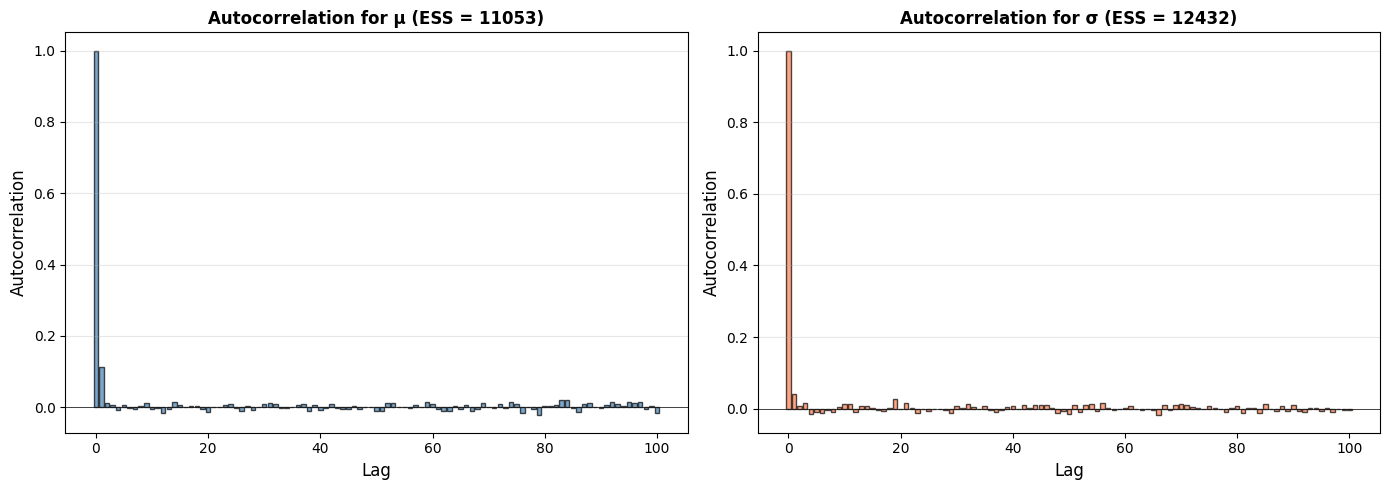

In [5]:
# Combine all chains
combined_mu = np.asarray(np.concatenate(chains_mu), dtype=float)
combined_sigma = np.asarray(np.concatenate(chains_sigma), dtype=float)

# ESS with Numerics
ess_mu = float(MCMCDiagnostics.EffectiveSampleSize(convert_to_dotnet_array(combined_mu)))
ess_sigma = float(MCMCDiagnostics.EffectiveSampleSize(convert_to_dotnet_array(combined_sigma)))

ess_df = pd.DataFrame(
    {
        'Metric': ['Total samples', 'ESS (μ)', 'ESS efficiency (μ)', 'ESS (σ)', 'ESS efficiency (σ)'],
        'Value': [len(combined_mu), ess_mu, 100 * ess_mu / len(combined_mu), ess_sigma, 100 * ess_sigma / len(combined_sigma)],
    }
)
print("Effective Sample Size")
display(ess_df.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
max_lag = 100

# Autocorrelation from Numerics
acf_mu = Autocorrelation.Function(
    convert_to_dotnet_array(combined_mu),
    int(max_lag),
    Autocorrelation.Type.Correlation,
)
acf_sigma = Autocorrelation.Function(
    convert_to_dotnet_array(combined_sigma),
    int(max_lag),
    Autocorrelation.Type.Correlation,
)

lags_mu = np.array([int(acf_mu[i, 0]) for i in range(acf_mu.GetLength(0))], dtype=int)
autocorr_mu = np.array([float(acf_mu[i, 1]) for i in range(acf_mu.GetLength(0))], dtype=float)

lags_sigma = np.array([int(acf_sigma[i, 0]) for i in range(acf_sigma.GetLength(0))], dtype=int)
autocorr_sigma = np.array([float(acf_sigma[i, 1]) for i in range(acf_sigma.GetLength(0))], dtype=float)

axes[0].bar(lags_mu, autocorr_mu, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_xlabel('Lag', fontsize=12)
axes[0].set_ylabel('Autocorrelation', fontsize=12)
axes[0].set_title(f'Autocorrelation for μ (ESS = {ess_mu:.0f})', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(lags_sigma, autocorr_sigma, alpha=0.7, color='coral', edgecolor='black')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Lag', fontsize=12)
axes[1].set_ylabel('Autocorrelation', fontsize=12)
axes[1].set_title(f'Autocorrelation for σ (ESS = {ess_sigma:.0f})', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()



## 4. Adaptive Sampling (ARWMH)

ARWMH automatically tunes the proposal distribution during burn-in for optimal acceptance rates.

Target acceptance rate: ~23-44% for multivariate problems.

Adaptive RWMH Results


,Metric,Value,True
0,μ estimate,100.606,100.0
1,σ estimate,15.026,15.0
2,ESS (μ),13773.302,NaN
3,ESS (σ),11596.742,NaN


Acceptance rates by chain


,Chain,Acceptance Rate
0,0,0.377
1,1,0.377
2,2,0.371
3,3,0.371


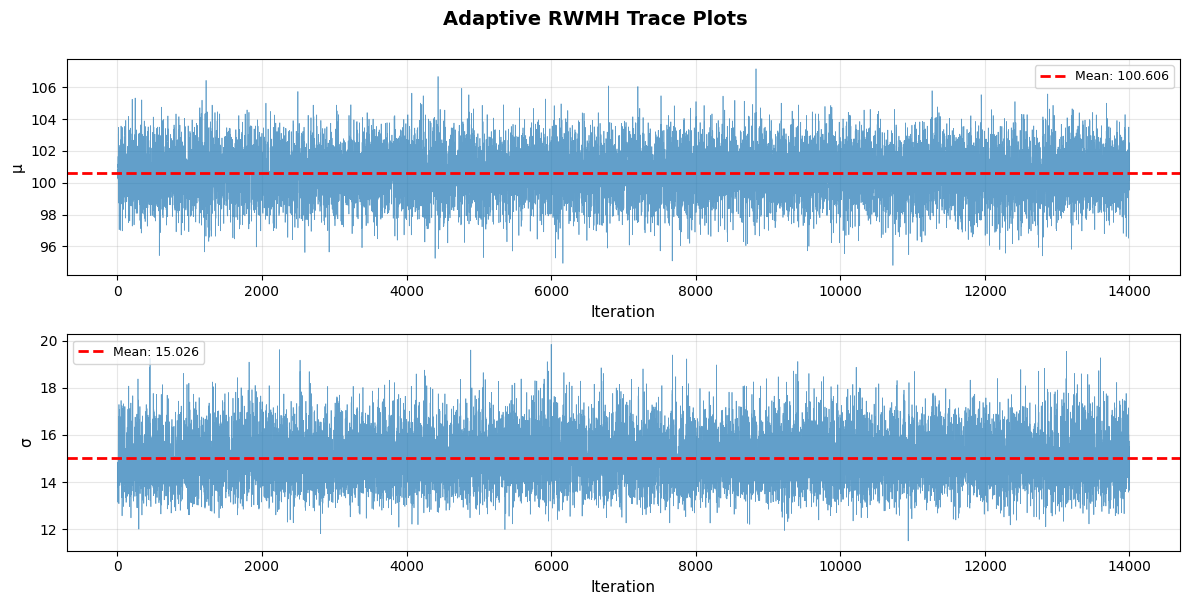

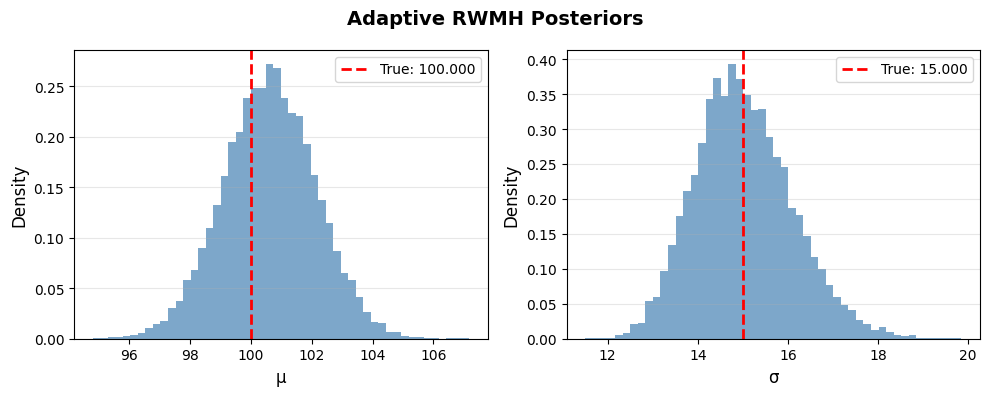

In [6]:
# Create ARWMH sampler
arwmh = ARWMH(priors, log_lik_func)
arwmh.BurnIn = 2000
arwmh.SampleSize = 5000
arwmh.Sample()
arwmh_results = MCMCResults(arwmh)

mu_samples = extract_chain_samples(arwmh_results, 0)
sigma_samples = extract_chain_samples(arwmh_results, 1)
combined_mu = np.asarray(np.concatenate(mu_samples), dtype=float)
combined_sigma = np.asarray(np.concatenate(sigma_samples), dtype=float)

ess_mu = float(MCMCDiagnostics.EffectiveSampleSize(convert_to_dotnet_array(combined_mu)))
ess_sigma = float(MCMCDiagnostics.EffectiveSampleSize(convert_to_dotnet_array(combined_sigma)))

arwmh_df = pd.DataFrame(
    {
        'Metric': ['μ estimate', 'σ estimate', 'ESS (μ)', 'ESS (σ)'],
        'Value': [np.mean(combined_mu), np.mean(combined_sigma), ess_mu, ess_sigma],
        'True': [true_mu, true_sigma, np.nan, np.nan],
    }
)
print("Adaptive RWMH Results")
display(arwmh_df.round(3))

acc_df = pd.DataFrame({'Chain': list(range(len(arwmh.AcceptanceRates))), 'Acceptance Rate': list(arwmh.AcceptanceRates)})
print("Acceptance rates by chain")
display(acc_df.round(3))

plot_trace([combined_mu, combined_sigma], ['μ', 'σ'], title="Adaptive RWMH Trace Plots")
plot_posterior([combined_mu, combined_sigma], ['μ', 'σ'], [true_mu, true_sigma], title="Adaptive RWMH Posteriors")


## 5. Handling Multimodal Posteriors

Some posteriors have multiple peaks. DEMCz and DEMCzs are better at exploring these.

Fitting mixture model with DEMCz...

Mixture Model Estimates:


,Parameter,Mean,Weight
0,μ1,98.48,0.5
1,σ1,10.93,0.5
2,μ2,100.51,0.5
3,σ2,10.87,0.5


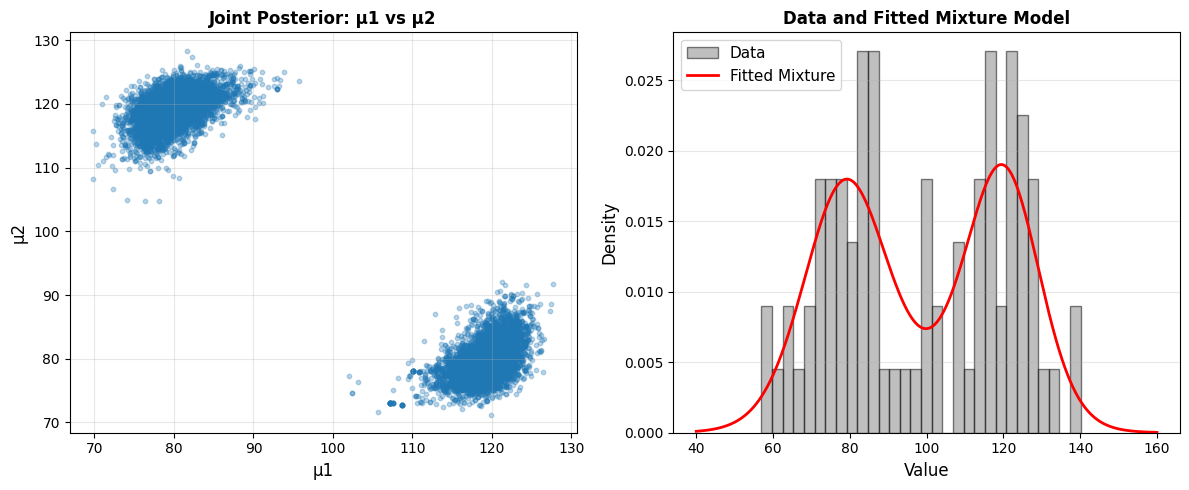

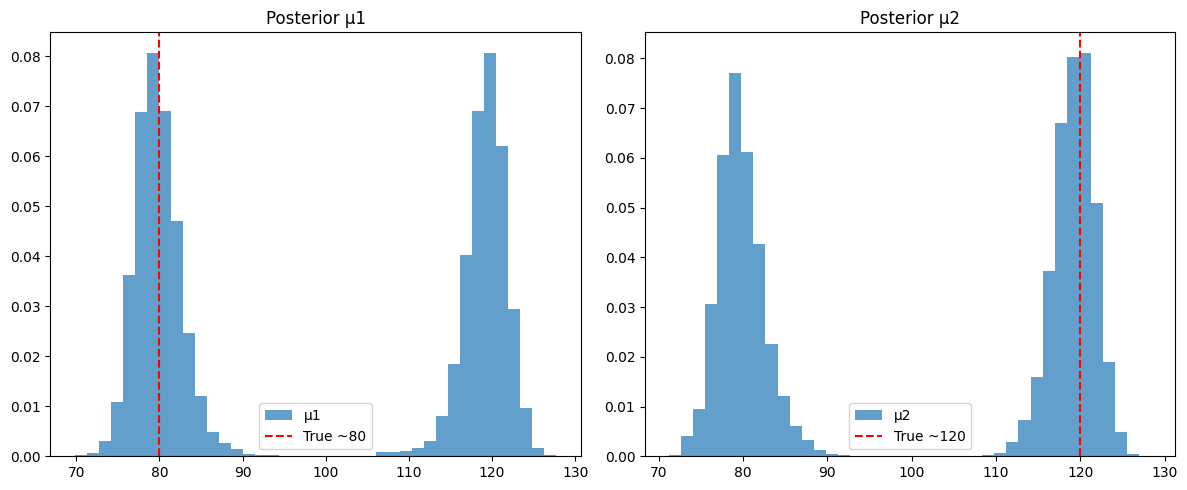

In [7]:
# Create bimodal mixture data
np.random.seed(789)
mode1 = Normal(80, 10).GenerateRandomValues(40, 789)
mode2 = Normal(120, 10).GenerateRandomValues(40, 789)
bimodal_data = np.concatenate([list(mode1), list(mode2)])
bimodal_net = convert_to_dotnet_array(bimodal_data)

# Priors for mixture model
priors_mixture = List[IUnivariateDistribution]()
priors_mixture.Add(Uniform(50, 150))   # mu1
priors_mixture.Add(Uniform(5, 20))     # sigma1
priors_mixture.Add(Uniform(50, 150))   # mu2
priors_mixture.Add(Uniform(5, 20))     # sigma2
priors_mixture.Add(Uniform(0.01, 0.99))  # weight

# Mixture model log-likelihood
def log_lik_mixture(params):
    mu1, sigma1, mu2, sigma2, weight = params[0], params[1], params[2], params[3], params[4]
    
    dist1 = Normal(mu1, sigma1)
    dist2 = Normal(mu2, sigma2)
    
    total_ll = 0
    for x in bimodal_data:
        prob = weight * np.exp(dist1.LogPDF(x)) + (1 - weight) * np.exp(dist2.LogPDF(x))
        if prob > 0:
            total_ll += np.log(prob)
        else:
            total_ll += -1e10
    
    return total_ll

log_lik_mixture_func = LogLikelihood(log_lik_mixture)

# Use DEMCz for multimodal posterior
print("Fitting mixture model with DEMCz...")
demcz = DEMCz(priors_mixture, log_lik_mixture_func)
demcz.BurnIn = 3000
demcz.SampleSize = 10000

demcz.Sample()
results = MCMCResults(demcz)

mu1_chains = extract_chain_samples(results, 0)
sigma1_chains = extract_chain_samples(results, 1)
mu2_chains = extract_chain_samples(results, 2)
sigma2_chains = extract_chain_samples(results, 3)
weight_chains = extract_chain_samples(results, 4)

mu1_samples = np.concatenate(mu1_chains)
sigma1_samples = np.concatenate(sigma1_chains)
mu2_samples = np.concatenate(mu2_chains)
sigma2_samples = np.concatenate(sigma2_chains)
weight_samples = np.concatenate(weight_chains)

print("\nMixture Model Estimates:")
summary_table = pd.DataFrame({
    'Parameter': ['μ1', 'σ1', 'μ2', 'σ2'],
    'Mean': [np.mean(mu1_samples), np.mean(sigma1_samples), np.mean(mu2_samples), np.mean(sigma2_samples)],
    'Weight': np.mean(weight_samples)
})
display(summary_table.round(2))

# Joint posterior plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(mu1_samples, mu2_samples, alpha=0.3, s=10)
plt.xlabel('μ1', fontsize=12)
plt.ylabel('μ2', fontsize=12)
plt.title('Joint Posterior: μ1 vs μ2', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(bimodal_data, bins=30, density=True, alpha=0.5, color='gray', 
         edgecolor='black', label='Data')
x_range = np.linspace(40, 160, 500)
mean_weight = np.mean(weight_samples)


# Use a subset of posterior samples to approximate posterior predictive
idx = np.random.choice(len(mu1_samples), size=min(1000, len(mu1_samples)), replace=False)

pdf_mixture = []
for x in x_range:
    vals = []
    for j in idx:
        d1 = Normal(mu1_samples[j], sigma1_samples[j])
        d2 = Normal(mu2_samples[j], sigma2_samples[j])
        vals.append(weight_samples[j] * d1.PDF(x) + (1 - weight_samples[j]) * d2.PDF(x))
    pdf_mixture.append(np.mean(vals))

plt.plot(x_range, pdf_mixture, 'r-', linewidth=2, label='Fitted Mixture')
plt.xlabel('Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Data and Fitted Mixture Model', fontsize=12, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Marginal posterior plots
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(mu1_samples, bins=40, alpha=0.7, density=True, label='μ1')
plt.axvline(80, color='red', linestyle='--', label='True ~80')
plt.legend(); plt.title('Posterior μ1')

plt.subplot(1,2,2)
plt.hist(mu2_samples, bins=40, alpha=0.7, density=True, label='μ2')
plt.axvline(120, color='red', linestyle='--', label='True ~120')
plt.legend(); plt.title('Posterior μ2')

plt.tight_layout()
plt.show()


## 6. Comparing MCMC Samplers

Different samplers have different strengths. Let's compare:

- **RWMH**: Random Walk Metropolis-Hastings (basic)
- **ARWMH**: Adaptive Random Walk MH (auto-tuning)
- **DEMCz**: Differential Evolution MCMC (population-based)
- **DEMCzs**: DEMCz with snooker update (better for complex posteriors)
- **HMC**: Hamiltonian Monte Carlo (uses gradients)

### Weibull Distribution Example

Fit a Weibull distribution to reliability data using different samplers.

In [8]:
# Generate Weibull data (failure times)
np.random.seed(123)
true_lambda = 100
true_kappa = 2.5
failure_times = list(Weibull(true_lambda, true_kappa).GenerateRandomValues(50, 12345))

priors_weibull = List[IUnivariateDistribution]()
priors_weibull.Add(Uniform(50, 200))
priors_weibull.Add(Uniform(1, 5))

def log_lik_weibull(params):
    dist = Weibull(params[0], params[1])
    return sum(dist.LogPDF(x) for x in failure_times)

log_lik_weibull_func = LogLikelihood(log_lik_weibull)

samplers_to_test = {
    'RWMH': lambda: RWMH(priors_weibull, log_lik_weibull_func, proposal),
    'ARWMH': lambda: ARWMH(priors_weibull, log_lik_weibull_func),
    'DEMCz': lambda: DEMCz(priors_weibull, log_lik_weibull_func),
    'DEMCzs': lambda: DEMCzs(priors_weibull, log_lik_weibull_func),
    # 'HMC' : lambda: HMC(priors_weibull, log_lik_weibull_func)  takes 20+ minutes to run on its own
}

out_results = {}
summary_rows = []
print("Comparing MCMC samplers...")

for name, create_sampler in samplers_to_test.items():
    print(f"Running {name}...")
    sampler = create_sampler()
    sampler.BurnIn = 1000
    sampler.SampleSize = 5000

    import time
    start = time.time()
    sampler.Sample()
    elapsed = time.time() - start

    results = MCMCResults(sampler)
    chains_lambda = extract_chain_samples(results, 0)
    chains_kappa = extract_chain_samples(results, 1)

    combined_lambda = np.asarray(np.concatenate(chains_lambda), dtype=float)
    combined_kappa = np.asarray(np.concatenate(chains_kappa), dtype=float)

    est_lambda = np.mean(combined_lambda)
    est_kappa = np.mean(combined_kappa)
    ess_lambda = float(MCMCDiagnostics.EffectiveSampleSize(convert_to_dotnet_array(combined_lambda))) if combined_lambda.size > 0 else 0.0
    ess_kappa = float(MCMCDiagnostics.EffectiveSampleSize(convert_to_dotnet_array(combined_kappa))) if combined_kappa.size > 0 else 0.0

    out_results[name] = {'lambda': combined_lambda, 'kappa': combined_kappa, 'time': elapsed, 'ess_lambda': ess_lambda, 'ess_kappa': ess_kappa}

    summary_rows.append({'Sampler': name, 'Runtime (s)': elapsed, 'λ Estimate': est_lambda, 'κ Estimate': est_kappa, 'λ Error': est_lambda - true_lambda, 'κ Error': est_kappa - true_kappa, 'ESS (λ)': ess_lambda, 'ESS (κ)': ess_kappa})

summary_df = pd.DataFrame(summary_rows).sort_values('Runtime (s)')
print("Sampler comparison summary")
display(summary_df.round(3))



Comparing MCMC samplers...
Running RWMH...
Running ARWMH...
Running DEMCz...
Running DEMCzs...
Sampler comparison summary


,Sampler,Runtime (s),λ Estimate,κ Estimate,λ Error,κ Error,ESS (λ),ESS (κ)
0,RWMH,135.809,108.889,2.690,8.889,0.190,636.074,5570.070
2,DEMCz,139.423,108.899,2.689,8.899,0.189,12179.087,12712.395
3,DEMCzs,142.574,108.914,2.695,8.914,0.195,12984.905,13318.703
1,ARWMH,147.533,108.938,2.691,8.938,0.191,13357.007,13772.278


Sampler Comparison:


,Sampler,Time (s),λ Mean,λ Std,κ Mean,κ Std,ESS (λ),ESS (κ)
0,RWMH,135.808511,108.888903,6.107407,2.690116,0.313513,636.073523,5570.069748
1,ARWMH,147.533287,108.938437,6.107734,2.690764,0.310923,13357.006800,13772.278203
2,DEMCz,139.422567,108.898943,6.099182,2.688722,0.313687,12179.086520,12712.395400
3,DEMCzs,142.574147,108.913684,6.108234,2.694957,0.316359,12984.904907,13318.702972



True values: λ = 100, κ = 2.5


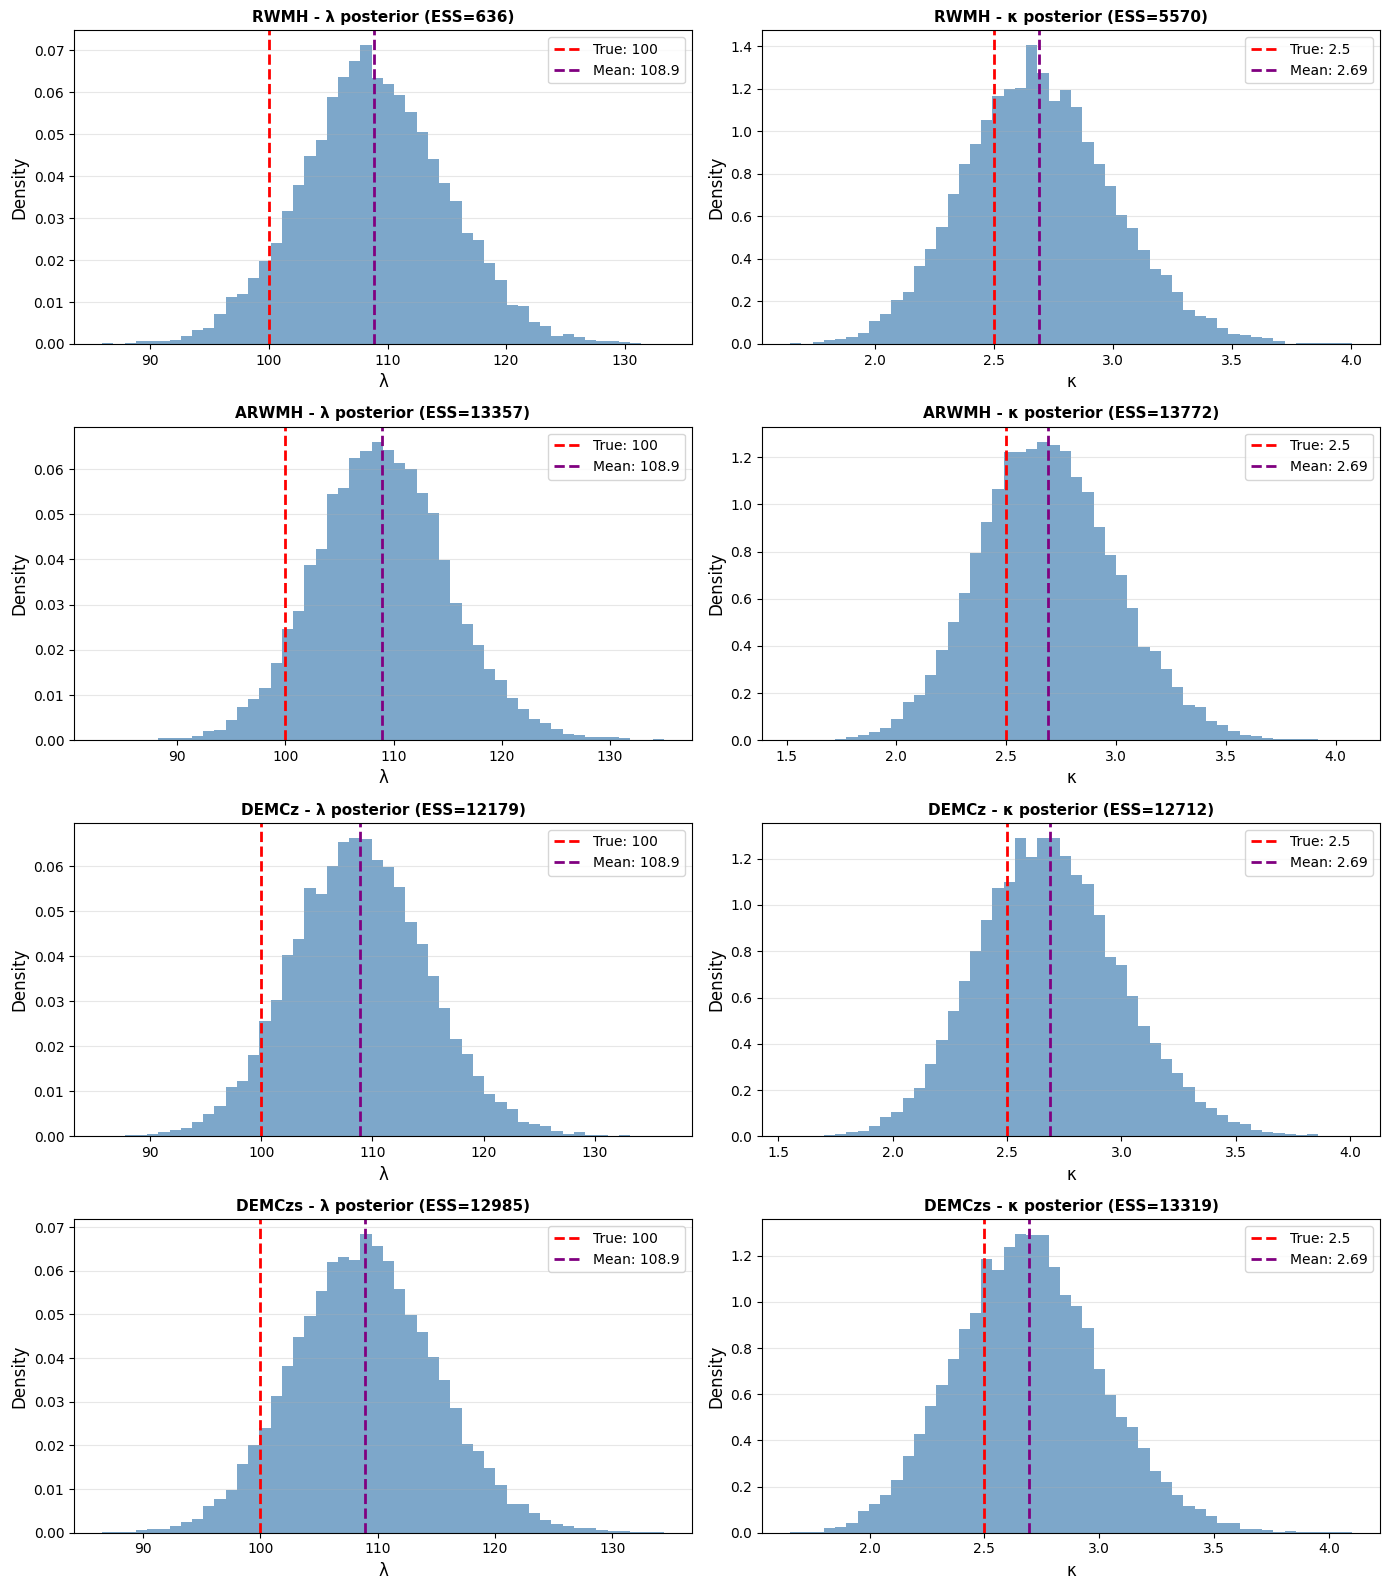

In [11]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Sampler': list(out_results.keys()),
    'Time (s)': [out_results[s]['time'] for s in out_results],
    'λ Mean': [np.mean(out_results[s]['lambda']) for s in out_results],
    'λ Std': [np.std(out_results[s]['lambda']) for s in out_results],
    'κ Mean': [np.mean(out_results[s]['kappa']) for s in out_results],
    'κ Std': [np.std(out_results[s]['kappa']) for s in out_results],
    'ESS (λ)': [out_results[s]['ess_lambda'] for s in out_results],
    'ESS (κ)': [out_results[s]['ess_kappa'] for s in out_results]
})

print("Sampler Comparison:")
display(comparison_df)
print(f"\nTrue values: λ = {true_lambda}, κ = {true_kappa}")

# Plot comparison
fig, axes = plt.subplots(len(out_results), 2, figsize=(14, 4*len(out_results)))

colors = ['steelblue', 'steelblue', 'steelblue', 'steelblue']

for i, (name, res) in enumerate(out_results.items()):
    # Lambda
    axes[i, 0].hist(res['lambda'], bins=50, density=True, alpha=0.7, 
                    color='steelblue')
    axes[i, 0].axvline(true_lambda, color='red', linestyle='--', linewidth=2, 
                       label=f'True: {true_lambda}')
    axes[i, 0].axvline(np.mean(res['lambda']), color='purple', linestyle='--', 
                       linewidth=2, label=f'Mean: {np.mean(res["lambda"]):.1f}')
    axes[i, 0].set_xlabel('λ', fontsize=12)
    axes[i, 0].set_ylabel('Density', fontsize=12)
    axes[i, 0].set_title(f'{name} - λ posterior (ESS={res["ess_lambda"]:.0f})', 
                        fontsize=11, fontweight='bold')
    axes[i, 0].legend(fontsize=10)
    axes[i, 0].grid(True, alpha=0.3, axis='y')
    
    # Kappa
    axes[i, 1].hist(res['kappa'], bins=50, density=True, alpha=0.7, 
                    color='steelblue')
    axes[i, 1].axvline(true_kappa, color='red', linestyle='--', linewidth=2, 
                       label=f'True: {true_kappa}')
    axes[i, 1].axvline(np.mean(res['kappa']), color='purple', linestyle='--', 
                       linewidth=2, label=f'Mean: {np.mean(res["kappa"]):.2f}')
    axes[i, 1].set_xlabel('κ', fontsize=12)
    axes[i, 1].set_ylabel('Density', fontsize=12)
    axes[i, 1].set_title(f'{name} - κ posterior (ESS={res["ess_kappa"]:.0f})', 
                        fontsize=11, fontweight='bold')
    axes[i, 1].legend(fontsize=10)
    axes[i, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Tuning Tips and Best Practices

### General Guidelines

1. **Burn-in**: Use 10-50% of total iterations
2. **Sample size**: At least 1000 effective samples
3. **Multiple chains**: Run 3-4 chains to assess convergence
4. **Thinning**: Usually not necessary with modern samplers

### Sampler Selection

- **Simple problems**: RWMH or ARWMH
- **High dimensions**: DEMCz, DEMCzs
- **Multimodal**: DEMCzs
- **Smooth gradients available**: HMC
- **Computational budget limited**: ARWMH

### Troubleshooting

- **Low acceptance rate (<10%)**: Proposal too wide
- **High acceptance rate (>80%)**: Proposal too narrow
- **High autocorrelation**: Increase samples or use different sampler
- **R-hat > 1.1**: Run longer or check for bugs

## Summary

You've learned:

✓ Running multiple chains for convergence diagnostics      
✓ Computing R-hat and ESS      
✓ Comparing different MCMC samplers        
✓ Adaptive sampling with ARWMH     
✓ Handling multimodal posteriors with DEMCz        
✓ Best practices for MCMC      

## Key Takeaways

1. **Always check convergence** - Use R-hat and visual inspection
2. **ESS matters more than raw samples** - Account for autocorrelation
3. **Different samplers for different problems** - No one-size-fits-all
4. **Adaptive methods reduce tuning burden** - ARWMH, DEMCz are robust
5. **Multiple chains catch problems early** - Run at least 3-4 chains

## Next Steps

- **06_optimization.ipynb** - Optimization algorithms
- **04_mcmc_bayesian_inference.ipynb** - Real-world Bayesian modeling

## Exercise

1. Generate data from a Gamma distribution
2. Fit using 3 different MCMC samplers
3. Compare ESS and convergence
4. Which sampler performs best?